# Mangosteen Dataset v4 — Balanced augmentation > INT8
โน้ตบุ๊กนี้ใช้ไฟล์ **Mangosteen_Dataset_v2_color_clean.zip** ที่จัดใหม่แล้ว

สิ่งที่แก้จากรุ่นเดิม:
- ตัดขอบภาพที่มีกรอบแดง
- พักภาพสีก้ำกึ่ง 20 ภาพ ไม่ใช้ฝึกหรือทดสอบ
- แบ่งช่วงภาพที่ถ่ายติดกันให้อยู่ชุดเดียวกัน
- ใช้ CNN ใหม่และจำกัด class weight เพื่อลดอาการทายเป็นคลาสเดียว
- ตรวจ Float32 และ INT8 แยกกัน

เป้าหมายของอาจารย์คือ Overall accuracy >90% แต่ต้องดูผล Test หลังรันจริง

In [ ]:
import os, zipfile, json, shutil, tempfile, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from google.colab import files
tf.keras.utils.set_random_seed(42)
print("TensorFlow:",tf.__version__,"GPU:",tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1) อัปโหลด Dataset ZIP
เลือกไฟล์ **Mangosteen_Dataset_v2_color_clean.zip** ที่ดาวน์โหลดจากแชต

In [ ]:
uploaded=files.upload()
zip_name=next((n for n in uploaded if n.endswith(".zip")),None)
assert zip_name, "กรุณาอัปโหลดไฟล์ ZIP"
WORK=Path(tempfile.mkdtemp(prefix="mangosteen_v2_"))
with zipfile.ZipFile(zip_name) as z:
    z.extractall(WORK)
DATA=WORK/"Mangosteen_Dataset_v2_color_clean"
assert DATA.exists(), "ไม่พบโฟลเดอร์ Dataset ใน ZIP"
print((DATA/"summary.json").read_text())

Saving Mangosteen_Dataset_v2_color_clean.zip to Mangosteen_Dataset_v2_color_clean.zip
{
  "train": {
    "unripe": 74,
    "ripe": 58,
    "overripe": 19
  },
  "val": {
    "unripe": 15,
    "ripe": 11,
    "overripe": 4
  },
  "test": {
    "unripe": 20,
    "ripe": 12,
    "overripe": 4
  },
  "uncertain": 20
}


## 2) โหลดข้อมูล
ลำดับคลาสนี้ต้องใช้เหมือนกันตอนลง ESP32-S3

In [ ]:
CLASS_NAMES=["unripe","ripe","overripe"]
IMG_SIZE=(96,96)
BATCH=16
def dataset(split,shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        DATA/split,class_names=CLASS_NAMES,label_mode="int",
        image_size=IMG_SIZE,batch_size=BATCH,shuffle=shuffle,seed=42)
train_ds=dataset("train",True)
val_ds=dataset("val",False)
test_ds=dataset("test",False)
AUTOTUNE=tf.data.AUTOTUNE
train_ds=train_ds.prefetch(AUTOTUNE)
val_ds=val_ds.cache().prefetch(AUTOTUNE)
test_ds=test_ds.cache().prefetch(AUTOTUNE)

Found 151 files belonging to 3 classes.
Found 30 files belonging to 3 classes.
Found 36 files belonging to 3 classes.


## 3) ดูภาพตัวอย่าง
ตรวจว่าสีและป้ายกำกับตรงกันก่อนเทรน

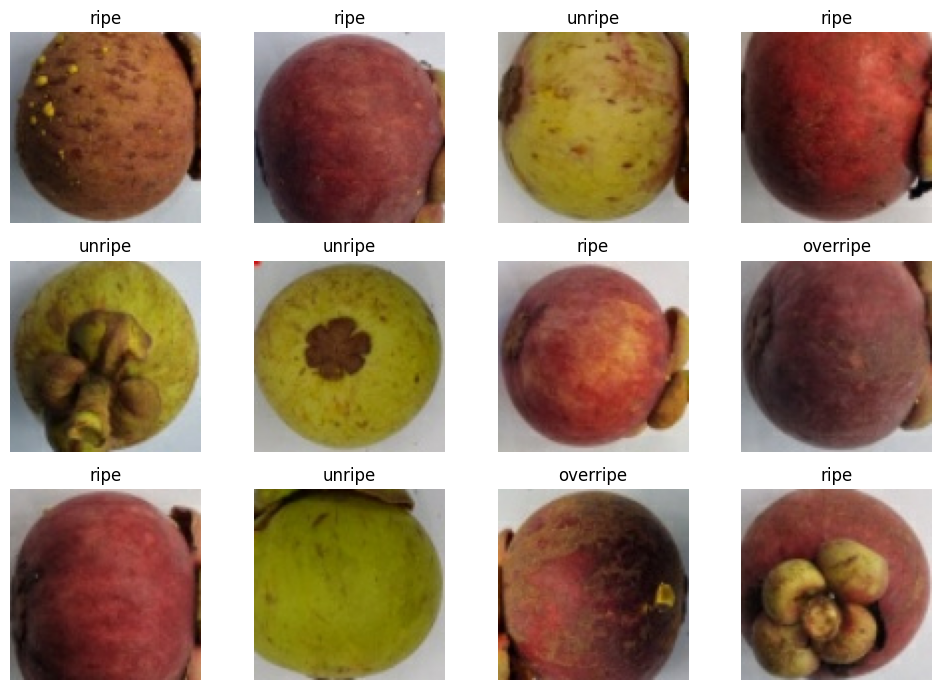

In [ ]:
plt.figure(figsize=(10,7))
for images,labels in train_ds.take(1):
    for i in range(min(12,len(images))):
        plt.subplot(3,4,i+1);plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])]);plt.axis("off")
plt.tight_layout();plt.show()

## 4) สร้าง CNN ขนาดเล็ก
โมเดลนี้ไม่เกิน 100,000 parameters และยังใช้ได้กับ TFLite Micro

In [ ]:
L=tf.keras.layers
augment=tf.keras.Sequential([
    L.RandomFlip("horizontal_and_vertical"),
    L.RandomRotation(0.50,fill_mode="reflect"),
    L.RandomZoom(0.08)
],name="augmentation")
def make_model():
    inp=L.Input((96,96,3))
    x=inp
    x=L.Rescaling(1./255)(x)
    color=L.AveragePooling2D(pool_size=8)(x)
    color=L.Flatten()(color)
    for filters in (16,32,64):
        x=L.Conv2D(filters,3,padding="same",use_bias=False)(x)
        x=L.BatchNormalization()(x);x=L.ReLU()(x);x=L.MaxPooling2D()(x)
    x=L.SeparableConv2D(96,3,padding="same",use_bias=False)(x)
    x=L.BatchNormalization()(x);x=L.ReLU()(x)
    x=L.GlobalAveragePooling2D()(x)
    x=L.Concatenate()([x,color])
    x=L.Dense(64,activation="relu")(x);x=L.Dropout(.25)(x)
    out=L.Dense(3,activation="softmax")(x)
    return tf.keras.Model(inp,out,name="mangosteen_color_cnn_v3")
model=make_model()
assert model.count_params()<=100000
model.summary()

Model: "mangosteen_color_cnn_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │      4,608 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 24,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 24,    │     18,432 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 12,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 12, 12,    │      6,720 │ max_pooling2d_2[… │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        384 │ separable_conv2d… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 12, 12,    │          0 │ batch_normalizat

 Total params: 65,075 (254.20 KB)

 Trainable params: 64,659 (252.57 KB)

 Non-trainable params: 416 (1.62 KB)

## 5) ทดสอบว่าโมเดลจำตัวอย่างเล็ก ๆ ได้
เป็นการตรวจโค้ด ไม่ใช่คะแนนส่งอาจารย์ หาก Training accuracy ต่ำกว่า 85% ให้หยุดและส่งผลมา

In [ ]:
small_x,small_y=next(iter(train_ds))
sanity=make_model()
sanity.compile(tf.keras.optimizers.Adam(1e-3),"sparse_categorical_crossentropy",metrics=["accuracy"])
h=sanity.fit(small_x,small_y,epochs=80,batch_size=len(small_x),verbose=0)
sanity_acc=h.history["accuracy"][-1]
print(f"Sanity training accuracy: {sanity_acc:.2%}")
if sanity_acc<.85:
    raise RuntimeError("โมเดลยังจำชุดเล็กไม่ได้ กรุณาส่งผลเซลล์นี้มาตรวจ")

Sanity training accuracy: 100.00%


## 6) เทรนเต็มชุด
สุ่มแต่ละคลาสให้สมดุล หมุน/พลิกเฉพาะ Train และเลือกโมเดลด้วย Balanced Accuracy ของ Validation

Epoch 1/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.6562 - loss: 0.8031 - val_accuracy: 0.3667 - val_loss: 1.4600 - learning_rate: 5.0000e-04
Epoch 2/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8611 - loss: 0.4567 - val_accuracy: 0.3667 - val_loss: 1.3885 - learning_rate: 5.0000e-04
Epoch 3/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8819 - loss: 0.3709 - val_accuracy: 0.3667 - val_loss: 1.3517 - learning_rate: 5.0000e-04
Epoch 4/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9097 - loss: 0.2910 - val_accuracy: 0.3667 - val_loss: 1.2211 - learning_rate: 5.0000e-04
Epoch 5/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9410 - loss: 0.2355 - val_accuracy: 0.3667 - val_loss: 1.2997 - learning_rate: 5.0000e-04
Epoch 6/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9236 - loss: 0.2012 - val_accuracy: 0.3667 - val_loss: 1.2078 - learning_rate: 5.0000e-04
Epoch 7/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy

seed 73 validation balanced accuracy 1.0
Chosen seed: 11


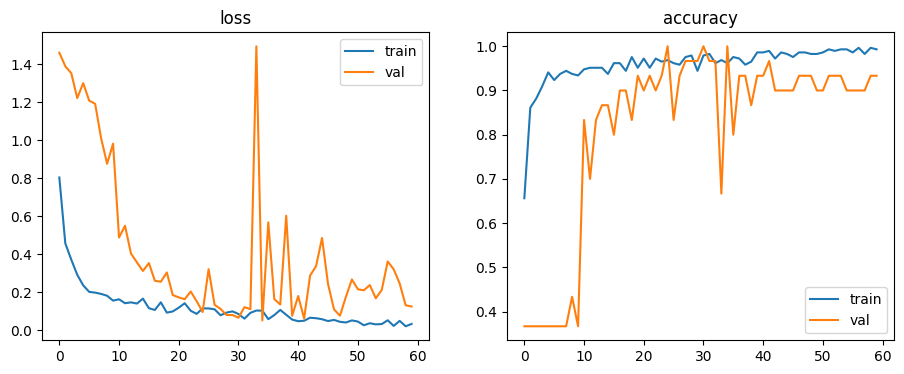

In [ ]:
base_train=train_ds.unbatch()
class_streams=[]
for class_id in range(3):
    ds=base_train.filter(lambda x,y,class_id=class_id: tf.equal(y,class_id)).shuffle(100,seed=100+class_id).repeat()
    class_streams.append(ds)
balanced=tf.data.Dataset.sample_from_datasets(class_streams,weights=[0.30,0.30,0.40],seed=42)
train_aug=balanced.batch(BATCH).map(lambda x,y:(augment(x,training=True),y),num_parallel_calls=tf.data.AUTOTUNE).take(18).prefetch(tf.data.AUTOTUNE)
runs=[]
for run_seed in [11,42,73]:
    tf.keras.backend.clear_session();tf.keras.utils.set_random_seed(run_seed)
    candidate=make_model()
    candidate.compile(tf.keras.optimizers.Adam(5e-4),"sparse_categorical_crossentropy",metrics=["accuracy"])
    run_path=WORK/f"candidate_{run_seed}.keras"
    h=candidate.fit(train_aug,validation_data=val_ds,epochs=120,verbose=1,callbacks=[
      tf.keras.callbacks.ModelCheckpoint(run_path,monitor="val_loss",mode="min",save_best_only=True),
      tf.keras.callbacks.EarlyStopping(monitor="val_loss",mode="min",patience=25),
      tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",patience=7,factor=.5,min_lr=1e-6)])
    candidate=tf.keras.models.load_model(run_path)
    vy=[];vp=[]
    for vx,vt in val_ds:
        vy.extend(vt.numpy());vp.extend(candidate.predict(vx,verbose=0).argmax(1))
    val_bal=balanced_accuracy_score(vy,vp)
    print("seed",run_seed,"validation balanced accuracy",val_bal)
    runs.append((val_bal,run_seed,candidate,h))
_,chosen_seed,model,history=max(runs,key=lambda x:x[0])
best=WORK/"best_mangosteen_v4.keras";model.save(best)
print("Chosen seed:",chosen_seed)
hist=pd.DataFrame(history.history)
hist.to_csv(WORK/"training_history.csv",index=False)
fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,m in zip(ax,["loss","accuracy"]):
    a.plot(hist[m],label="train");a.plot(hist["val_"+m],label="val");a.set_title(m);a.legend()
plt.show()

## 7) ประเมิน Float32
คะแนนสำหรับรายงานควรดู Test ซึ่งไม่ใช้เลือกโมเดล

Validation Float32 accuracy: 1.0 balanced: 1.0
              precision    recall  f1-score   support

      unripe       1.00      1.00      1.00        15
        ripe       1.00      1.00      1.00        11
    overripe       1.00      1.00      1.00         4

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



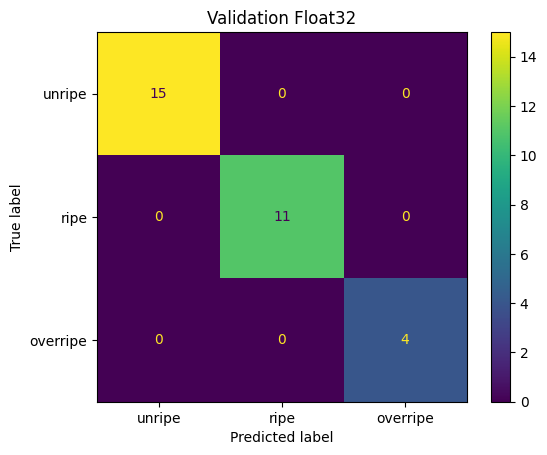

Test Float32 accuracy: 0.9722222222222222 balanced: 0.9166666666666666
              precision    recall  f1-score   support

      unripe       1.00      1.00      1.00        20
        ripe       0.92      1.00      0.96        12
    overripe       1.00      0.75      0.86         4

    accuracy                           0.97        36
   macro avg       0.97      0.92      0.94        36
weighted avg       0.97      0.97      0.97        36



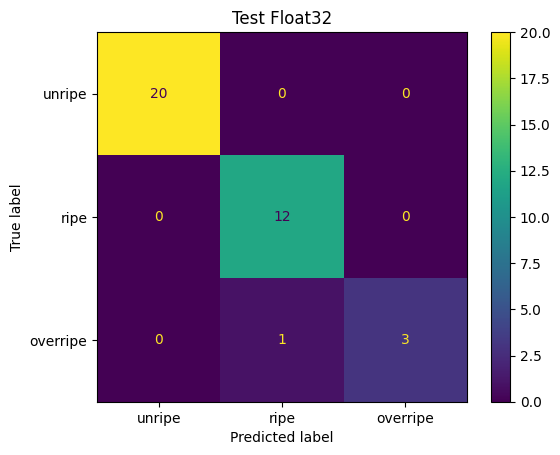

In [ ]:
def keras_result(ds,name):
    y=[];p=[]
    for x,t in ds:
        y.extend(t.numpy());p.extend(model.predict(x,verbose=0).argmax(1))
    y=np.array(y);p=np.array(p)
    print(name,"accuracy:",accuracy_score(y,p),"balanced:",balanced_accuracy_score(y,p))
    print(classification_report(y,p,target_names=CLASS_NAMES,zero_division=0))
    ConfusionMatrixDisplay(confusion_matrix(y,p),display_labels=CLASS_NAMES).plot()
    plt.title(name);plt.show()
    return y,p,accuracy_score(y,p)
yv,pv,val_float=keras_result(val_ds,"Validation Float32")
yt,pt,test_float=keras_result(test_ds,"Test Float32")

## 8) แปลง Full INT8 และประเมิน
Calibration ใช้เฉพาะ Train

Saved artifact at '/tmp/tmpczgd1t4r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140658390812240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390618320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390629072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390810896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390811664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390615824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390624656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390627152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390624272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390624848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140658390625040: 

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Test Float32: 97.22%
Test INT8: 100.00%
INT8 drop: -2.78 percentage points
ผ่าน >90%: True
              precision    recall  f1-score   support

      unripe       1.00      1.00      1.00        20
        ripe       1.00      1.00      1.00        12
    overripe       1.00      1.00      1.00         4

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



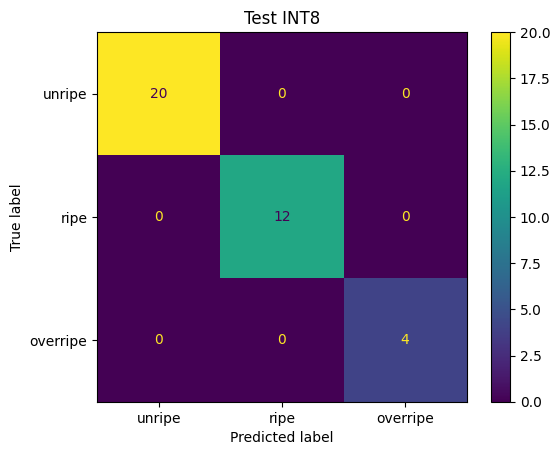

In [ ]:
def representative():
    n=0
    for x,_ in train_ds:
        for one in x:
            yield [one[None].numpy().astype(np.float32)]
            n+=1
            if n>=120:return
converter=tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations=[tf.lite.Optimize.DEFAULT]
converter.representative_dataset=representative
converter.target_spec.supported_ops=[tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type=tf.int8
converter.inference_output_type=tf.int8
int8_model=converter.convert()
tflite_path=WORK/"mangosteen_v4_int8.tflite"
tflite_path.write_bytes(int8_model)
def lite_predict(ds):
    inter=tf.lite.Interpreter(model_content=int8_model);inter.allocate_tensors()
    inp=inter.get_input_details()[0];out=inter.get_output_details()[0]
    ys=[];ps=[];scale,zero=inp["quantization"];lo,hi=np.iinfo(inp["dtype"]).min,np.iinfo(inp["dtype"]).max
    for xb,yb in ds:
        for x,y in zip(xb.numpy(),yb.numpy()):
            q=np.clip(np.rint(x/scale+zero),lo,hi).astype(inp["dtype"])[None]
            inter.set_tensor(inp["index"],q);inter.invoke()
            ps.append(int(inter.get_tensor(out["index"])[0].argmax()));ys.append(int(y))
    return np.array(ys),np.array(ps)
yi,pi=lite_predict(test_ds)
test_int8=accuracy_score(yi,pi)
print(f"Test Float32: {test_float:.2%}")
print(f"Test INT8: {test_int8:.2%}")
print(f"INT8 drop: {100*(test_float-test_int8):.2f} percentage points")
print("ผ่าน >90%:",test_int8>.90)
print(classification_report(yi,pi,target_names=CLASS_NAMES,zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(yi,pi),display_labels=CLASS_NAMES).plot()
plt.title("Test INT8");plt.show()

## 9) ดาวน์โหลดผลลัพธ์
ส่งภาพผล Test และ ZIP นี้มาให้ตรวจ ก่อนนำโมเดลลงบอร์ด

In [ ]:
(WORK/"class_names.json").write_text(json.dumps(CLASS_NAMES))
metrics={"validation_float32":float(val_float),"test_float32":float(test_float),
         "test_int8":float(test_int8),"int8_drop_percentage_points":float(100*(test_float-test_int8)),
         "parameters":int(model.count_params())}
(WORK/"metrics.json").write_text(json.dumps(metrics,indent=2))
result=WORK/"Mangosteen_v4_training_results.zip"
with zipfile.ZipFile(result,"w",zipfile.ZIP_DEFLATED) as z:
    for p in [best,tflite_path,WORK/"class_names.json",WORK/"metrics.json",WORK/"training_history.csv"]:
        z.write(p,p.name)
files.download(str(result))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>